# CytoFM Embedding t-SNE: Round #1 vs Round #2

For each class (Benign, Malignant, Suspicious), we sample 100 images from Round #1
(AnnotatedDataSet_old) and 100 from Round #2 (AnnotatedDataSet), extract CytoFM backbone
embeddings (768-dim CLS token), and visualise with t-SNE coloured by dataset.

If Round #1 and Round #2 occupy clearly different regions, that would explain why
models trained on Round #1 don't generalise well to Round #2.

In [1]:
import sys
import random
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from sklearn.manifold import TSNE

SEED = 42
N_SAMPLES = 100
CLASSES = ["Benign", "Malignant", "Suspicious"]

ROOT = Path("../../..")
sys.path.insert(0, str(ROOT))

OLD_DIR = ROOT / "data/raw/AnnotatedDataSet_old"
NEW_DIR = ROOT / "data/raw/AnnotatedDataSet"
CKPT    = ROOT / "models/cytofm_weights.pth"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("mps" if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


In [2]:
from src.models.architectures.cytofm import load_cytofm

backbone = load_cytofm(str(CKPT), device)
backbone.eval()
print(f"Backbone loaded — embed_dim: {backbone.embed_dim}")

Backbone loaded — embed_dim: 768


In [3]:
# Same transforms used in training (ImageNet normalisation, resize to 224)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

def get_embeddings(img_paths, batch_size=16):
    """Run images through CytoFM backbone and return CLS token embeddings."""
    all_embs = []
    for i in range(0, len(img_paths), batch_size):
        batch_paths = img_paths[i:i + batch_size]
        tensors = torch.stack([
            transform(Image.open(p).convert("RGB"))
            for p in batch_paths
        ]).to(device)
        with torch.no_grad():
            embs = backbone(tensors)   # (B, 768) — CLS token
        all_embs.append(embs.cpu().float().numpy())
    return np.concatenate(all_embs, axis=0)

def sample_paths(class_dir, n):
    paths = list(class_dir.glob("*.png"))
    return random.sample(paths, min(n, len(paths)))

In [4]:
# Extract embeddings for all 3 classes
class_data = {}  # cls -> {embs_old, embs_new}

for cls in CLASSES:
    print(f"\n{cls}:")
    old_paths = sample_paths(OLD_DIR / cls, N_SAMPLES)
    new_paths = sample_paths(NEW_DIR / cls, N_SAMPLES)
    print(f"  Sampled {len(old_paths)} old, {len(new_paths)} new")

    embs_old = get_embeddings(old_paths)
    embs_new = get_embeddings(new_paths)
    print(f"  Embeddings: old={embs_old.shape}, new={embs_new.shape}")

    class_data[cls] = {"old": embs_old, "new": embs_new}

print("\nDone extracting embeddings.")


Benign:
  Sampled 100 old, 100 new
  Embeddings: old=(100, 768), new=(100, 768)

Malignant:
  Sampled 100 old, 100 new
  Embeddings: old=(100, 768), new=(100, 768)

Suspicious:
  Sampled 100 old, 100 new
  Embeddings: old=(100, 768), new=(100, 768)

Done extracting embeddings.


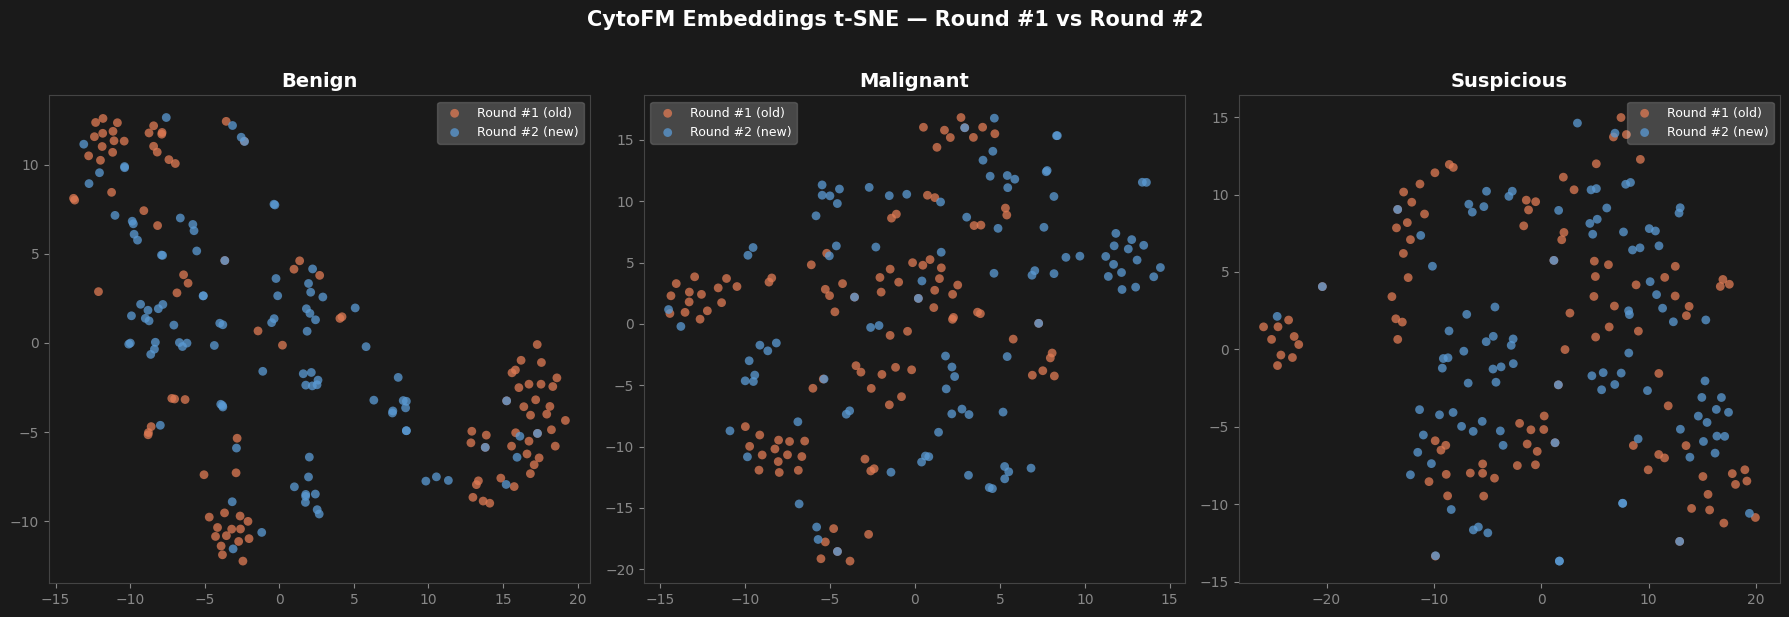

Saved: cytofm_tsne_r1_vs_r2.png


In [5]:
# t-SNE + plot — one subplot per class
OLD_COLOR = "#e07b54"
NEW_COLOR = "#5b9bd5"

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor("#1a1a1a")

for ax, cls in zip(axes, CLASSES):
    embs_old = class_data[cls]["old"]
    embs_new = class_data[cls]["new"]

    combined = np.concatenate([embs_old, embs_new], axis=0)
    labels   = np.array([0] * len(embs_old) + [1] * len(embs_new))

    tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
    proj = tsne.fit_transform(combined)

    ax.set_facecolor("#1a1a1a")
    ax.scatter(proj[labels == 0, 0], proj[labels == 0, 1],
               c=OLD_COLOR, alpha=0.75, s=40, label="Round #1 (old)", edgecolors="none")
    ax.scatter(proj[labels == 1, 0], proj[labels == 1, 1],
               c=NEW_COLOR, alpha=0.75, s=40, label="Round #2 (new)", edgecolors="none")

    ax.set_title(cls, color="white", fontsize=14, fontweight="bold")
    ax.tick_params(colors="#888888")
    for spine in ax.spines.values():
        spine.set_edgecolor("#444444")
    ax.legend(framealpha=0.2, labelcolor="white", fontsize=9)

fig.suptitle(
    "CytoFM Embeddings t-SNE — Round #1 vs Round #2",
    color="white", fontsize=15, fontweight="bold", y=1.02
)
plt.tight_layout()

out = Path("cytofm_tsne_r1_vs_r2.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")

## Class Separation: Round #1 vs Round #2

For each dataset separately, t-SNE is run on 300 images (100 per class), coloured by class.

If Round #1 shows tighter, more separated clusters than Round #2, that suggests the older
dataset has cleaner annotation or less inter-class ambiguity — which would explain lower
model performance on Round #2 despite its larger size.

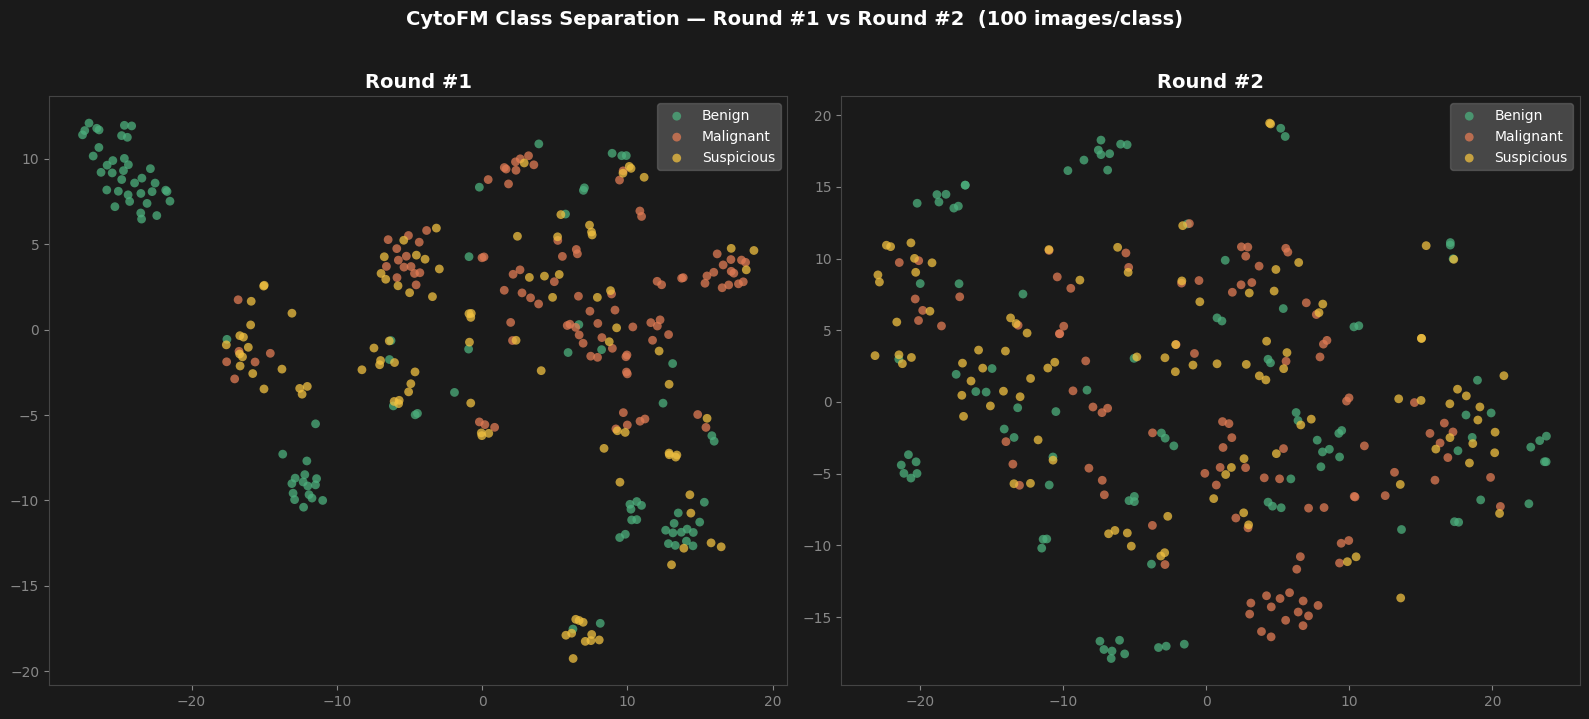

Saved: cytofm_tsne_class_separation.png


In [6]:
CLASS_COLORS = {
    "Benign":     "#4caf7d",
    "Malignant":  "#e07b54",
    "Suspicious": "#f0c040",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor("#1a1a1a")

for ax, (dataset_key, title) in zip(axes, [("old", "Round #1"), ("new", "Round #2")]):
    # Stack embeddings for all 3 classes
    all_embs   = np.concatenate([class_data[cls][dataset_key] for cls in CLASSES], axis=0)
    all_labels = np.concatenate([[cls] * N_SAMPLES for cls in CLASSES])

    tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
    proj = tsne.fit_transform(all_embs)

    ax.set_facecolor("#1a1a1a")
    for cls in CLASSES:
        mask = all_labels == cls
        ax.scatter(proj[mask, 0], proj[mask, 1],
                   c=CLASS_COLORS[cls], alpha=0.75, s=40,
                   label=cls, edgecolors="none")

    ax.set_title(title, color="white", fontsize=14, fontweight="bold")
    ax.tick_params(colors="#888888")
    for spine in ax.spines.values():
        spine.set_edgecolor("#444444")
    ax.legend(framealpha=0.2, labelcolor="white", fontsize=10)

fig.suptitle(
    "CytoFM Class Separation — Round #1 vs Round #2  (100 images/class)",
    color="white", fontsize=14, fontweight="bold", y=1.02
)
plt.tight_layout()

out = Path("cytofm_tsne_class_separation.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")

## PCA: Round #1 vs Round #2

PCA projects the 768-dim CytoFM embeddings onto the two directions of greatest variance.
Unlike t-SNE, the axes are linear and interpretable: PC1 captures the single largest source
of variation in each class, PC2 the second largest. The percentage of total variance each
component explains is shown at the bottom of each subplot.

In [7]:
from sklearn.decomposition import PCA

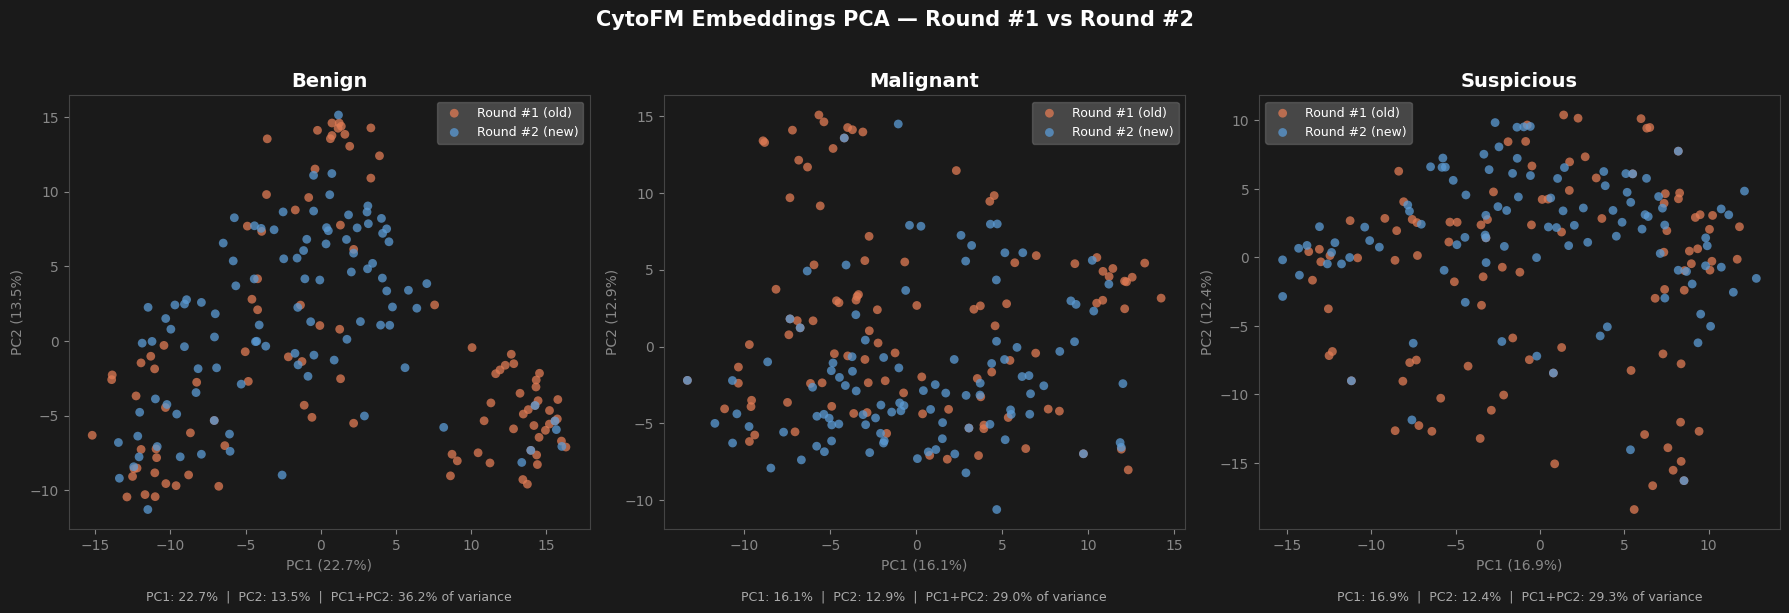

Saved: cytofm_pca_r1_vs_r2.png


In [8]:
# PCA — one subplot per class, Round #1 vs Round #2
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor("#1a1a1a")

for ax, cls in zip(axes, CLASSES):
    embs_old = class_data[cls]["old"]
    embs_new = class_data[cls]["new"]

    combined = np.concatenate([embs_old, embs_new], axis=0)
    labels   = np.array([0] * len(embs_old) + [1] * len(embs_new))

    pca  = PCA(n_components=2, random_state=SEED)
    proj = pca.fit_transform(combined)
    var1, var2 = pca.explained_variance_ratio_ * 100

    ax.set_facecolor("#1a1a1a")
    ax.scatter(proj[labels == 0, 0], proj[labels == 0, 1],
               c=OLD_COLOR, alpha=0.75, s=40, label="Round #1 (old)", edgecolors="none")
    ax.scatter(proj[labels == 1, 0], proj[labels == 1, 1],
               c=NEW_COLOR, alpha=0.75, s=40, label="Round #2 (new)", edgecolors="none")

    ax.set_title(cls, color="white", fontsize=14, fontweight="bold")
    ax.set_xlabel(f"PC1 ({var1:.1f}%)", color="#888888", fontsize=10)
    ax.set_ylabel(f"PC2 ({var2:.1f}%)", color="#888888", fontsize=10)
    ax.tick_params(colors="#888888")
    for spine in ax.spines.values():
        spine.set_edgecolor("#444444")
    ax.legend(framealpha=0.2, labelcolor="white", fontsize=9)

    ax.text(
        0.5, -0.14,
        f"PC1: {var1:.1f}%  |  PC2: {var2:.1f}%  |  PC1+PC2: {var1 + var2:.1f}% of variance",
        transform=ax.transAxes, ha="center", va="top",
        color="#aaaaaa", fontsize=9,
    )

fig.suptitle(
    "CytoFM Embeddings PCA — Round #1 vs Round #2",
    color="white", fontsize=15, fontweight="bold", y=1.02,
)
plt.tight_layout()

out = Path("cytofm_pca_r1_vs_r2.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")

## Linear Probe: Round #1 vs Round #2

A logistic regression is trained on the raw 768-dim CytoFM embeddings to predict
whether an image comes from Round #1 (old) or Round #2 (new).

**Why this matters:** if the probe achieves high accuracy, the two rounds are linearly
separable in embedding space — meaning the domain shift is real and large enough that
even a simple classifier can detect it from features alone.

**Slide-level split:** every patch image encodes its parent slide's staining and tissue
characteristics. All 15 slides in Round #1 also appear in Round #2, so a random
image-level split would leak slide-specific signal across train/test. Instead, we group
by slide ID and use `GroupShuffleSplit` so that every image from a given slide — regardless
of round — sits entirely in train or entirely in test.

In [9]:
import re
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix

def slide_id(path):
    """Extract true slide ID, stripping per-image timestamp prefixes."""
    name = path.stem
    base = name.split("_lux_")[0] if "_lux_" in name else name
    m = re.match(r'^\d{4}-\d{2}-\d{2}T[\d-]+Z-(.+?)(?:\.tif)?$', base)
    return m.group(1).lower() if m else base.lower()

In [10]:
# Collect embeddings per class — use ALL images from both rounds.
# balance() in the next cell handles equalisation after the slide split,
# so test slides keep their full image complement.
class_probe = {}  # cls -> {X, y, groups}

for cls in CLASSES:
    old_paths = sorted((OLD_DIR / cls).glob("*.png"))
    all_new   = sorted((NEW_DIR / cls).glob("*.png"))

    old_slide_ids = {slide_id(p) for p in old_paths}
    new_paths     = [p for p in all_new if slide_id(p) not in old_slide_ids]

    print(f"{cls}: Round #1: {len(old_paths)} imgs / {len(old_slide_ids)} slides, "
          f"Round #2 (excl. shared): {len(new_paths)} imgs / "
          f"{len({slide_id(p) for p in new_paths})} slides")

    embs_old = get_embeddings(old_paths)
    embs_new = get_embeddings(new_paths)

    X_cls      = np.concatenate([embs_old, embs_new], axis=0)
    y_cls      = np.array([0] * len(old_paths) + [1] * len(new_paths))
    groups_cls = np.array(
        [slide_id(p) for p in old_paths] +
        [slide_id(p) for p in new_paths]
    )
    class_probe[cls] = {"X": X_cls, "y": y_cls, "groups": groups_cls}

print("\nDone embedding.")

Benign: Round #1: 246 imgs / 13 slides, Round #2 (excl. shared): 971 imgs / 45 slides
Malignant: Round #1: 421 imgs / 10 slides, Round #2 (excl. shared): 1252 imgs / 42 slides
Suspicious: Round #1: 150 imgs / 14 slides, Round #2 (excl. shared): 1519 imgs / 49 slides

Done embedding.


Benign
  PCA variance captured (50 components): 87.5%
  Train — 220+220 imgs / 42 slides
  Test  — 26+26 imgs / 9 slides
  Overall accuracy : 26.9%
  Round #1 accuracy: 15.4%
  Round #2 accuracy: 38.5%

Malignant
  PCA variance captured (50 components): 85.7%
  Train — 334+334 imgs / 37 slides
  Test  — 87+87 imgs / 11 slides
  Overall accuracy : 52.3%
  Round #1 accuracy: 51.7%
  Round #2 accuracy: 52.9%

Suspicious
  PCA variance captured (50 components): 88.9%
  Train — 93+93 imgs / 38 slides
  Test  — 57+57 imgs / 11 slides
  Overall accuracy : 64.9%
  Round #1 accuracy: 40.4%
  Round #2 accuracy: 89.5%



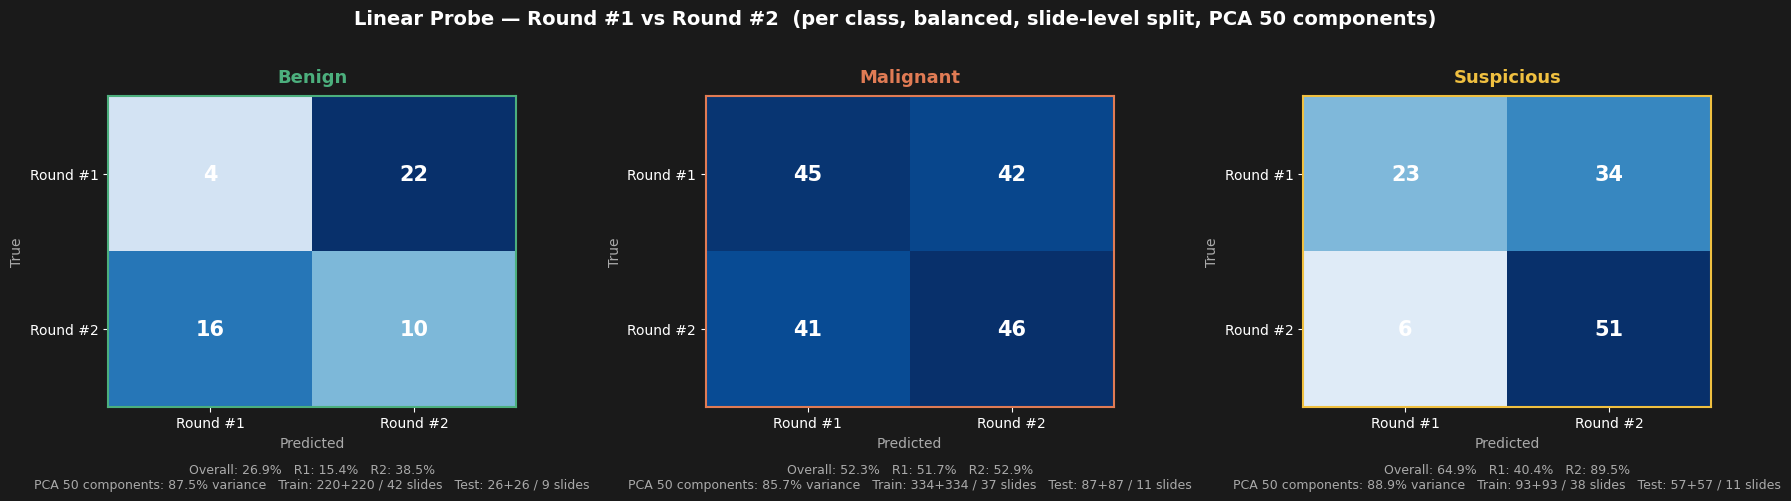

Saved: cytofm_linear_probe.png


In [11]:
# Train one logistic regression per class; plot 1×3 confusion matrices
# Pipeline: balance → PCA(50) fitted on train only → LogisticRegression
N_PCA = 50
gss   = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)

def balance(idx, y, rng):
    idx_r1 = idx[y[idx] == 0]
    idx_r2 = idx[y[idx] == 1]
    n = min(len(idx_r1), len(idx_r2))
    return np.concatenate([
        rng.choice(idx_r1, n, replace=False),
        rng.choice(idx_r2, n, replace=False),
    ])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor("#1a1a1a")
fig.suptitle(
    "Linear Probe — Round #1 vs Round #2  "
    f"(per class, balanced, slide-level split, PCA {N_PCA} components)",
    color="white", fontsize=14, fontweight="bold", y=1.02,
)

for ax, cls in zip(axes, CLASSES):
    X      = class_probe[cls]["X"]
    y      = class_probe[cls]["y"]
    groups = class_probe[cls]["groups"]

    raw_train, raw_test = next(gss.split(X, y, groups))
    assert not (set(groups[raw_train]) & set(groups[raw_test])), \
        f"Slide leakage in {cls}!"

    rng       = np.random.default_rng(SEED)
    train_idx = balance(raw_train, y, rng)
    test_idx  = balance(raw_test,  y, rng)

    n_tr_r1     = int((y[train_idx] == 0).sum())
    n_te_r1     = int((y[test_idx]  == 0).sum())
    n_tr_slides = len(set(groups[train_idx]))
    n_te_slides = len(set(groups[test_idx]))

    # PCA fitted on train only, applied to both
    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X[train_idx])
    X_te_sc = scaler.transform(X[test_idx])

    pca     = PCA(n_components=N_PCA, random_state=SEED)
    X_train = pca.fit_transform(X_tr_sc)
    X_test  = pca.transform(X_te_sc)
    var_captured = pca.explained_variance_ratio_.sum() * 100

    clf    = LogisticRegression(max_iter=2000, random_state=SEED, C=1.0)
    clf.fit(X_train, y[train_idx])
    y_pred = clf.predict(X_test)

    cm     = confusion_matrix(y[test_idx], y_pred)
    acc    = accuracy_score(y[test_idx], y_pred)
    acc_r1 = cm[0, 0] / cm[0].sum()
    acc_r2 = cm[1, 1] / cm[1].sum()

    print(f"{cls}")
    print(f"  PCA variance captured ({N_PCA} components): {var_captured:.1f}%")
    print(f"  Train — {n_tr_r1}+{n_tr_r1} imgs / {n_tr_slides} slides")
    print(f"  Test  — {n_te_r1}+{n_te_r1} imgs / {n_te_slides} slides")
    print(f"  Overall accuracy : {acc:.1%}")
    print(f"  Round #1 accuracy: {acc_r1:.1%}")
    print(f"  Round #2 accuracy: {acc_r2:.1%}\n")

    # ── subplot ───────────────────────────────────────────────────────
    ax.set_facecolor("#1a1a1a")
    accent = CLASS_COLORS[cls]
    ax.imshow(cm, cmap="Blues", aspect="auto", vmin=0)

    tick_labels = ["Round #1", "Round #2"]
    ax.set_xticks([0, 1]); ax.set_xticklabels(tick_labels, color="white", fontsize=10)
    ax.set_yticks([0, 1]); ax.set_yticklabels(tick_labels, color="white", fontsize=10)
    ax.set_xlabel("Predicted", color="#aaaaaa", fontsize=10)
    ax.set_ylabel("True",      color="#aaaaaa", fontsize=10)
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor(accent)
        spine.set_linewidth(1.5)

    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white", fontsize=15, fontweight="bold")

    ax.set_title(cls, color=accent, fontsize=13, fontweight="bold", pad=10)

    summary = (
        f"Overall: {acc:.1%}   R1: {acc_r1:.1%}   R2: {acc_r2:.1%}\n"
        f"PCA {N_PCA} components: {var_captured:.1f}% variance   "
        f"Train: {n_tr_r1}+{n_tr_r1} / {n_tr_slides} slides   "
        f"Test: {n_te_r1}+{n_te_r1} / {n_te_slides} slides"
    )
    ax.text(0.5, -0.18, summary, transform=ax.transAxes,
            ha="center", va="top", color="#aaaaaa", fontsize=9)

plt.tight_layout()
out = Path("cytofm_linear_probe.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {out}")